In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from numpy.linalg import svd
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/Users/egor/Desktop/HSE/abalone_original.csv')
df.head()

,sex,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings
0,M,91,73,19,102.8,44.9,20.2,30.0,15
1,M,70,53,18,45.1,19.9,9.7,14.0,7
2,F,106,84,27,135.4,51.3,28.3,42.0,9
3,M,88,73,25,103.2,43.1,22.8,31.0,10
4,I,66,51,16,41.0,17.9,7.9,11.0,7


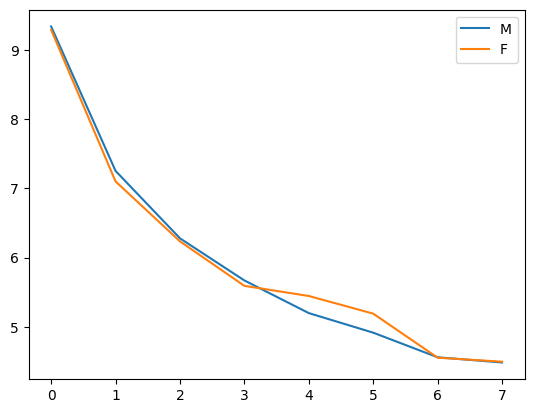

train score:  0.5388104838709677 test score:  0.5393654524089306
              precision    recall  f1-score   support

           F       0.00      0.00      0.00       392
           M       0.54      1.00      0.70       459

    accuracy                           0.54       851
   macro avg       0.27      0.50      0.35       851
weighted avg       0.29      0.54      0.38       851

              precision    recall  f1-score   support

           F       0.50      0.00      0.00       915
           M       0.54      1.00      0.70      1069

    accuracy                           0.54      1984
   macro avg       0.52      0.50      0.35      1984
weighted avg       0.52      0.54      0.38      1984



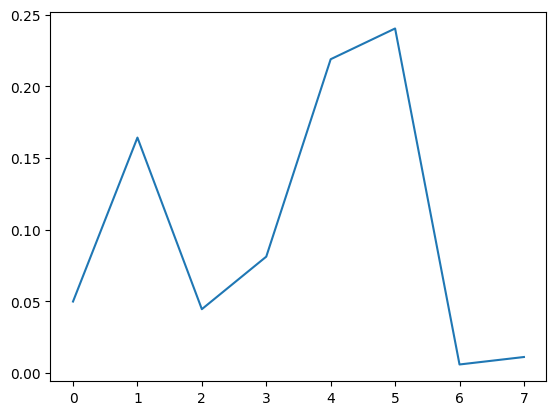

In [4]:
subset = df[df['sex'].isin(['F','M'])]
poly = PolynomialFeatures(1, include_bias = False, interaction_only = False)

S_list = []

for i in subset['sex'].unique():
    T = subset[subset['sex']==i].drop(columns = ['sex']).values
    T = poly.fit_transform(T)
    _, S, _ = svd(T)
    S_list.append(S)
    plt.plot(np.log(S), label = i)

plt.legend()
plt.show()

S_list = np.array(S_list)

ratio = np.abs((S_list[0,:]-S_list[1,:])/S_list[1,:])
plt.plot(ratio)

f = list(np.where(ratio > 0.2)[0])

X = subset.drop(columns = ['sex'])
y = subset['sex']

X = poly.fit_transform(X)
pca = PCA()
#pca = KernelPCA(kernel = 'rbf', gamma = 2)
X = pca.fit_transform(X)

X = X[:,f]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y, shuffle = True)

model = LogisticRegression(fit_intercept = True, penalty = 'elasticnet', l1_ratio = 0., solver = 'saga')
model = model.fit(X_train, y_train)

print('train score: ', model.score(X_train,y_train), 'test score: ', model.score(X_test,y_test))
print(classification_report(y_test, model.predict(X_test)))
print(classification_report(y_train, model.predict(X_train)))